In [26]:
import msprime
import numpy as np
from functools import partial
from IPython.display import SVG
def check_set_symmetric_migration_change(d1,d2,migration_rate,demography,height,width):
    if d2[0] >= 0 and d2[0] < height:
        if d2[1] >= 0 and d2[1] < width:
            #print(f'd{d1[0]+1}_{d1[1]+1} - {d2[0]+1}_{d2[1]+1}')
            demography.set_symmetric_migration_rate([name_generator(d1[0],d1[1]),name_generator(d2[0],d2[1])],migration_rate)
            return True
    return False
def name_generator(row,col):
    return f'd{row+1}_{col+1}'

In [27]:

demography = msprime.Demography()
width = 3
height = 3 
initial_size = 100
migration_rate = 0.05
dtwf_duration = 50
sample_size = 10



samples = {}
migration_partial = partial(check_set_symmetric_migration_change, migration_rate=migration_rate, demography=demography, height=height, width=width)
for row in range(height):
    for col in range(width):
        name = name_generator(row,col)
        demography.add_population(name=name,initial_size=initial_size)
        samples[name] = sample_size
for row in range(height):
    for col in range(width):
        coordinates = zip([row,row,row-1,row+1],[col-1,col+1,col,col])
        d1 = (row, col)
        print(list(map(lambda d2: migration_partial(d1,d2),coordinates)))
demography.add_population(name='pan',initial_size=initial_size,description='Ancestral population!')
demography.add_population_split(time=140,ancestral='pan',derived=np.arange(height*width))
model = [msprime.DiscreteTimeWrightFisher(duration=dtwf_duration),msprime.StandardCoalescent()]

            

[False, True, False, True]
[True, True, False, True]
[True, False, False, True]
[False, True, True, True]
[True, True, True, True]
[True, False, True, True]
[False, True, True, False]
[True, True, True, False]
[True, False, True, False]


In [22]:

recombination_rate = 1e-8
l = 1e7
border_list = []
head = 0
chr_count = 5
chr_length = 1e5
for i in range(chr_count):
    border_list.append( head )
    border_list.append( head + chr_length)
    head += chr_length+1
recomb_list = (chr_count*[.5, recombination_rate])[:-1]
rate_map = msprime.RateMap(position=border_list,rate=recomb_list)


In [24]:
random_seed = 1234

mu = 1e-8
ts = msprime.sim_ancestry(samples=samples,demography=demography,model= model,random_seed=random_seed,recombination_rate=rate_map)

KeyboardInterrupt: 

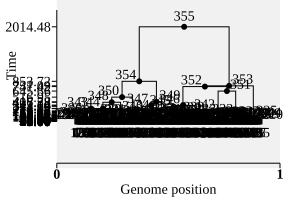

In [10]:
SVG(ts.draw_svg(y_axis=True,size=(300,200) ))

In [12]:
mts = msprime.sim_mutations(ts,rate=mu,random_seed=random_seed)

In [15]:
# ts_simplified = mts.simplify()
# SVG(ts_simplified.draw_svg())

In [16]:
ts_chroms = []
for j in range(len(chrom_positions) - 1):
    start, end = chrom_positions[j: j + 2]
    chrom_ts = ts.keep_intervals([[start, end]], simplify=False).trim()
    ts_chroms.append(chrom_ts)
    print(chrom_ts.sequence_length)

In [28]:
demography.debug()